# Logistic Regression using Scikit-Learn

In this notebook, we implement Logistic Regression using **scikit-learn**.

We will:
- Load dataset
- Preprocess data
- Train model
- Evaluate performance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Using built-in dataset
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Shape of X:", X.shape)
print("Classes:", np.unique(y))

Shape of X: (569, 30)
Classes: [0 1]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (455, 30)
Test size: (114, 30)


In [4]:
model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted classes:\n", y_pred[:10])
print("Predicted probabilities:\n", y_prob[:10])

Predicted classes:
 [1 0 0 1 1 0 0 0 1 1]
Predicted probabilities:
 [8.78866438e-01 2.92218247e-08 1.57695292e-03 9.98771648e-01
 9.99859481e-01 1.94300386e-10 5.81541344e-11 1.91027859e-02
 9.84677704e-01 9.94330647e-01]


In [6]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.956140350877193

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
 [[39  4]
 [ 1 70]]


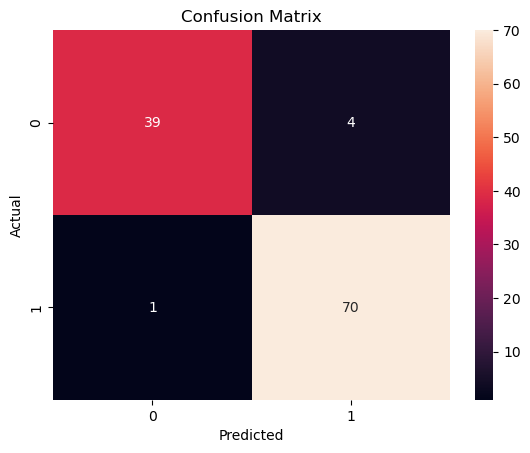

In [7]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Important Parameters in LogisticRegression

- penalty → 'l1', 'l2' (regularization)
- C → inverse of regularization strength
- solver → 'liblinear', 'lbfgs'
- max_iter → iterations for convergence

In [8]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000)
model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_test)

print("Accuracy with L1:", accuracy_score(y_test, y_pred_l1))

Accuracy with L1: 0.956140350877193


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


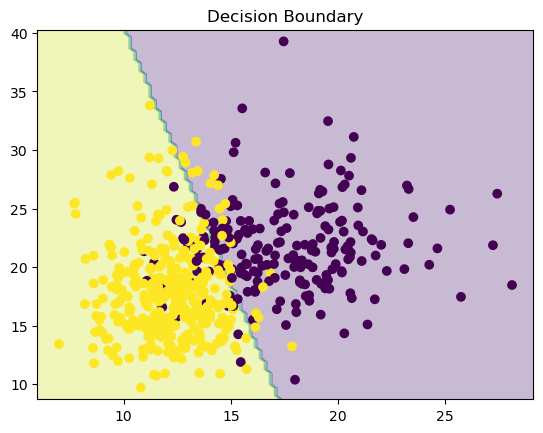

In [9]:
# Using only 2 features for visualization
X_vis = X.iloc[:, :2]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y, test_size=0.2, random_state=42
)

model_vis = LogisticRegression()
model_vis.fit(X_train_v, y_train_v)

# Plot
x_min, x_max = X_vis.iloc[:, 0].min()-1, X_vis.iloc[:, 0].max()+1
y_min, y_max = X_vis.iloc[:, 1].min()-1, X_vis.iloc[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis.iloc[:, 0], X_vis.iloc[:, 1], c=y)
plt.title("Decision Boundary")
plt.show()

## Summary

- Logistic Regression is easy & powerful baseline model
- Use `predict()` for classes, `predict_proba()` for probabilities
- Always evaluate using confusion matrix + classification report
- Regularization helps prevent overfitting